# Bagging vs Random Forest

## Why Are Bagging and Random Forest Different?

Although Random Forest is built on the idea of Bagging, they are **not exactly the same algorithm**.

The two major differences are:

### 1. Base Estimator Flexibility

**Bagging** is a general ensemble technique and can work with almost any machine learning algorithm.

Examples:

* Decision Trees
* Support Vector Machines (SVM)
* K-Nearest Neighbors (KNN)
* Logistic Regression

**Random Forest** is specialized and can only use **Decision Trees** as its base estimator.

---

### 2. Feature Sampling Strategy

Both algorithms perform bootstrap row sampling, but they differ in how feature columns are selected.

#### Bagging (with Decision Trees)

Feature sampling occurs **once before the tree starts growing**.

If a tree receives only two features:

$$
X_0,\ X_1
$$

then the entire tree can use only those two features from the root node to the leaf nodes.

#### Random Forest

Feature sampling occurs **at every node split**.

At each split, a random subset of features is selected and the best split is chosen from that subset.

This process repeats throughout the entire tree.

As a result, a single tree may use:

$$
X_1 \rightarrow X_4 \rightarrow X_2 \rightarrow X_0
$$

at different levels of the tree.

This creates significantly higher diversity among trees.

---

# 1. Architectural Difference

## Bagging (Bootstrap Aggregating)

Bagging is a general-purpose ensemble learning technique.

Characteristics:

* Can use any machine learning algorithm.
* Primarily designed to reduce variance.
* Most effective when used with high-variance models.
* Commonly paired with Decision Trees.

### Examples of Base Estimators

* Decision Tree
* SVM
* KNN
* Logistic Regression

---

## Random Forest

Random Forest is a specialized ensemble algorithm built exclusively around Decision Trees.

Characteristics:

* Uses only Decision Trees.
* Performs bootstrap row sampling.
* Performs feature sampling at every split.
* Produces highly diversified trees.
* Usually achieves better generalization than standard Bagging.

---

# 2. Tree-Level vs Node-Level Feature Sampling

## Bagging with Decision Trees

### Tree-Level Feature Selection

Feature columns are selected once before tree construction begins.

Example:

Suppose the dataset contains five features:

$$
X_0,\ X_1,\ X_2,\ X_3,\ X_4
$$

and:

```python
max_features = 2
```

A tree may randomly receive:

$$
X_0,\ X_1
$$

The tree is then restricted to only these features.

### Consequence

The entire tree uses only:

$$
X_0,\ X_1
$$

while:

$$
X_2,\ X_3,\ X_4
$$

are completely unavailable to that tree.

This limits diversity.

---

## Random Forest

### Node-Level Feature Selection

Feature sampling occurs at every split.

For each node:

1. Randomly select a subset of features.
2. Find the best split among them.
3. Create child nodes.
4. Repeat the process again.

### Consequence

A single path down a tree may use:

$$
X_1 \rightarrow X_4 \rightarrow X_2 \rightarrow X_3
$$

This allows every tree to explore many different feature combinations.

The trees become much less correlated with one another.

---

# 3. Why Random Forest Usually Performs Better

Random Forest introduces an additional layer of randomness beyond standard Bagging.

This creates:

* More diverse trees
* Lower correlation among trees
* Better variance reduction
* Better generalization on unseen data

As a result, Random Forest often outperforms Bagging with Decision Trees.

---

# 4. Summary Comparison

| Feature                | Bagging                 | Random Forest           |
| ---------------------- | ----------------------- | ----------------------- |
| Base Estimator         | Any ML algorithm        | Decision Trees only     |
| Row Sampling           | Bootstrap sampling      | Bootstrap sampling      |
| Feature Sampling       | Optional                | Built-in                |
| Feature Sampling Level | Tree Level              | Node Level              |
| Tree Diversity         | Moderate                | Very High               |
| Variance Reduction     | Good                    | Excellent               |
| Generalization         | Good                    | Usually Better          |
| Typical Use Case       | Any high-variance model | Decision Tree ensembles |

---

# Final Takeaway

A common misconception is:

> "Bagging with Decision Trees is the same as Random Forest."

This is incorrect.

Even when both models use Decision Trees:

* Bagging performs feature selection once per tree.
* Random Forest performs feature selection at every node.

This node-level randomness creates more diverse trees, lower correlation among estimators, stronger variance reduction, and usually better predictive performance.


In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.ensemble import BaggingClassifier,RandomForestClassifier
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

In [2]:
x,y = make_classification(n_features=5, n_redundant=0, n_informative=5,n_clusters_per_class=1)

In [3]:
df = pd.DataFrame(x,columns=['col1','col2','col3','col4','col5'])
df['target'] = y
print(df.shape)
df.head()

(100, 6)


,col1,col2,col3,col4,col5,target
0,-3.059940,-1.860373,0.716400,-1.390268,-0.064060,1
1,0.151364,1.568985,0.341081,1.012116,-1.716206,0
2,-1.372824,-0.690612,2.609595,0.415076,-1.252122,0
3,-1.470992,-1.618435,1.175776,-0.362367,-2.028703,0
4,-0.649282,0.160610,0.819635,0.284926,-1.925890,1


# Bagging  

In [4]:
bag = BaggingClassifier(max_features=2)

In [5]:
bag.fit(df.iloc[:,:5],df.iloc[:,-1])

,"estimator estimator: object, default=NoneThe base estimator to fit on random subsets of the dataset.If None, then the base estimator is a:class:`~sklearn.tree.DecisionTreeClassifier`... versionadded:: 1.2 `base_estimator` was renamed to `estimator`.",None
,"n_estimators n_estimators: int, default=10The number of base estimators in the ensemble.",10
,"max_samples max_samples: int or float, default=NoneThe number of samples to draw from X to train each base estimator (withreplacement by default, see `bootstrap` for more details).- If None, then draw `X.shape[0]` samples irrespective of `sample_weight`.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` unweighted samples or `max_samples * sample_weight.sum()` weighted samples.",None
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator (without replacement by default, see `bootstrap_features` for moredetails).- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.",2
,"bootstrap bootstrap: bool, default=TrueWhether samples are drawn with replacement. If False, sampling withoutreplacement is performed. If fitting with `sample_weight`, it isstrongly recommended to choose True, as only drawing with replacementwill ensure the expected frequency semantics of `sample_weight`.",True
,"bootstrap_features bootstrap_features: bool, default=FalseWhether features are drawn with replacement.",False
,"oob_score oob_score: bool, default=FalseWhether to use out-of-bag samples to estimatethe generalization error. Only available if bootstrap=True.",False
,"warm_start warm_start: bool, default=FalseWhen set to True, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fita whole new ensemble. See :term:`the Glossary `... versionadded:: 0.17 *warm_start* constructor parameter.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for both :meth:`fit` and:meth:`predict`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random resampling of the original dataset(sample wise and feature wise).If the base estimator accepts a `random_state` attribute, a differentseed is generated for each instance in the ensemble.Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",None
,"verbose verbose: int, default=0Controls the verbosity when fitting and predicting.",0


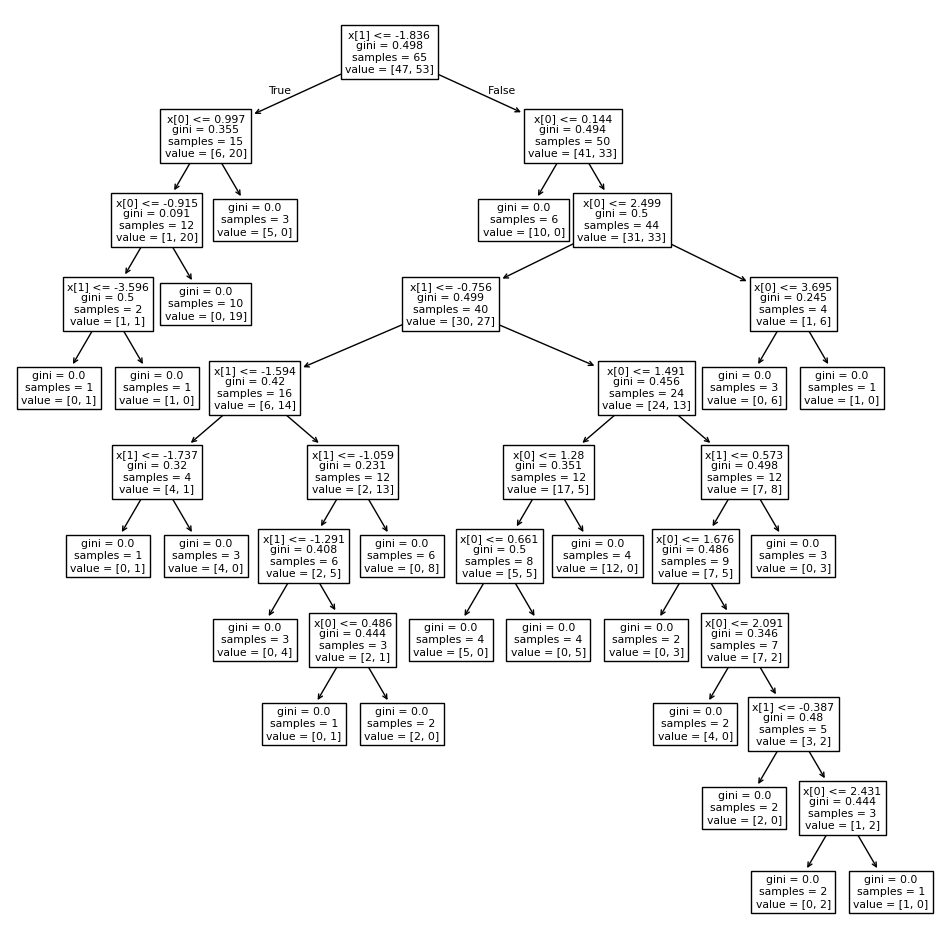

In [6]:
plt.figure(figsize=(12,12))
plot_tree(bag.estimators_[0])
plt.show()

In [7]:
# As we can see the whole tree have either col : X[0] or X[1] only  

# Random Forest 

In [8]:
rf = RandomForestClassifier(max_features=2)

In [9]:
rf.fit(df.iloc[:,:5],df.iloc[:,-1])

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",2
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y_tr

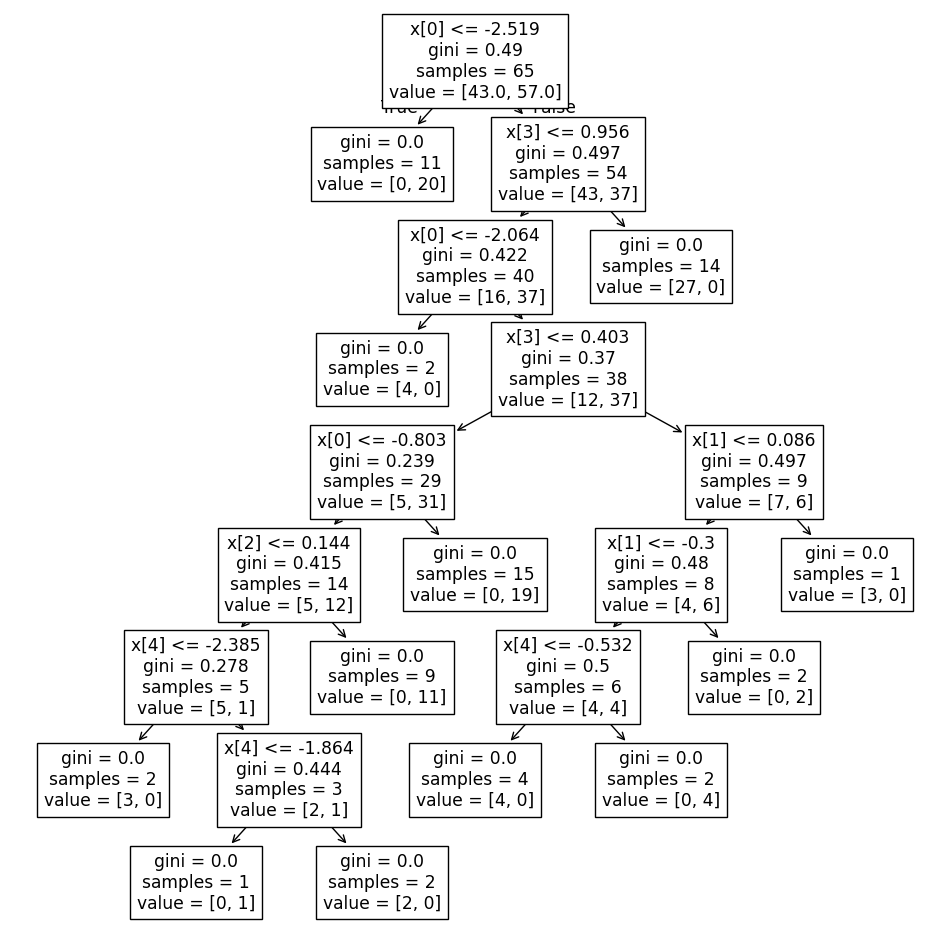

In [10]:
plt.figure(figsize=(12,12))
plot_tree(rf.estimators_[4])
plt.show()

In [11]:
# Even though we have sold to use 2 cols , RF choose those 3 cols at every node level . 
#  Cols use were : X[0] , X[1], X[2] , X[3],X[4]